## Dataset Selection - Kept for the record: outputs saved, data files not in repo

In [1]:
import pandas as pd
df = pd.read_csv("listings.csv.gz")
print(df.shape)

(92638, 90)


In [2]:
import glob
for f in glob.glob("uci_restaurant/*.csv"):
    d = pd.read_csv(f, encoding="latin-1")
    print(f, d.shape)

uci_restaurant/chefmozparking.csv (702, 2)
uci_restaurant/chefmozaccepts.csv (1314, 2)
uci_restaurant/userpayment.csv (177, 2)
uci_restaurant/geoplaces2.csv (130, 21)
uci_restaurant/rating_final.csv (1161, 5)
uci_restaurant/usercuisine.csv (330, 2)
uci_restaurant/chefmozcuisine.csv (916, 2)
uci_restaurant/chefmozhours4.csv (2339, 3)
uci_restaurant/userprofile.csv (138, 19)


## Dataset Check: UCI Restaurant vs. Inside Airbnb London

**Requirement (Lecture 1, slide 68):** ≥ 50,000 rows AND ≥ 20 features.

**UCI Restaurant & Consumer Data**
- 9 separate CSV files. The largest has 2,339 rows; all 9 combined total only 7,207 rows (about 14% of the minimum).
- Fails the row requirement. Merging or cleaning cannot fix this, because it only reshapes existing rows.
- Too small for a meaningful GPU (RAPIDS) vs. CPU comparison, which the rubric requires (slides 74, 84).

**Inside Airbnb London (snapshot: 19 June 2026)**
- Detailed listings file: 92,638 rows × 90 features. Meets both requirements.
- Large enough to show a measurable RAPIDS speedup.
- Public data, licensed CC BY 4.0.



In [3]:
food = pd.read_csv("archive.zip", sep="\t", low_memory=False)
print(food.shape)

(356027, 163)


In [4]:
for name, data in [("Food", food), ("London", df)]:
    usable = (data.isna().mean() < 0.5).sum()
    print(name, "columns at least half filled:", usable)

Food columns at least half filled: 34
London columns at least half filled: 76


In [5]:
print(food["nutrition_grade_fr"].notna().mean())
print(food["nutrition_grade_fr"].value_counts())
print(df["price"].notna().mean())

0.7158333497178585
nutrition_grade_fr
d    72436
c    52870
e    50236
a    40304
b    39010
Name: count, dtype: int64
0.6718625186208683


In [6]:
print(pd.to_datetime(food["created_datetime"], errors="coerce").max())

2017-09-18 01:35:39+00:00


In [7]:
cols = ["review_scores_rating", "availability_365", "number_of_reviews_ltm"]
print(df[[c for c in cols if c in df.columns]].notna().mean())

review_scores_rating     0.763304
availability_365         1.000000
number_of_reviews_ltm    1.000000
dtype: float64


In [8]:
r = df["review_scores_rating"].dropna()
print(r.describe())
print((r >= 4.8).mean())

count    70711.000000
mean         4.692911
std          0.482131
min          0.000000
25%          4.600000
50%          4.830000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64
0.5605209939047673


0.28628640514691595 0.03617306073101751


<Axes: >

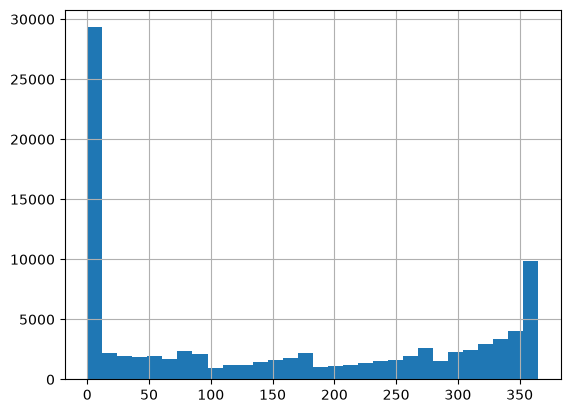

In [9]:
print((df["availability_365"] == 0).mean(), (df["availability_365"] == 365).mean())
df["availability_365"].hist(bins=30)

In [10]:
sub = [c for c in df.columns if c.startswith("review_scores_")]
print(df[sub].corr()["review_scores_rating"].sort_values())

review_scores_location         0.632566
review_scores_checkin          0.715640
review_scores_communication    0.787422
review_scores_cleanliness      0.796875
review_scores_accuracy         0.862326
review_scores_value            0.870374
review_scores_rating           1.000000
Name: review_scores_rating, dtype: float64


In [11]:
print([c for c in df.columns if "estimated" in c or "reviews" in c])

['number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'reviews_per_month']


In [12]:
r = df["review_scores_rating"]
print((r == 0).sum())
print((df.loc[r.isna(), "number_of_reviews"] == 0).mean())

3
1.0


In [13]:
print("host_is_superhost" in df.columns)

True
